# HPDM097 Assignment 2

## Iteration 9: 2nd new scenario (pooling of acute and rehab beds) (Gemini)

This is the 9th iteration to the code. Here we created a new scenario where we pool the acute and rehab beds both with the base stock of 22 beds and with an increased stock of 26 beds.

Prompt and response: https://gemini.google.com/share/4814e25a6a0c

## Prompt:
We don't have a final logic piece for ESD, but I would like to create a third scenario. On top of the previous two scenarios before, which I would like to keep in the code and be able to compare, I would like to create a third scenario: where the beds of both the acute stroke ward and the rehab ward can be pooled so that either patients can use either bed using the stock 22 beds and to also compare with an increased stock of 26 beds. This scenario will have the normal admission rates, not the increased 5% admission rates in scenario 2. Please give the p(delay) of both patients admitted to acute stroke ward and the rehab ward in this scenario. Again use the iterative process to add to the previous code and make it so that we can compare all 3 scenarios so far.

## Response
This is a fantastic use case for discrete event simulation. Pooling resources is a classic operations research strategy to reduce delays.

Because we are using an unconstrained (infinite capacity) model to measure the "offered load", calculating the pooled scenario is mathematically elegant. We don't actually need to rewrite the patient pathway to use a single simpy.Resource. In an infinite capacity system, if a patient transfers from an acute bed to a rehab bed, they release one and instantly occupy the other. Therefore, the sum of the occupants in both wards exactly equals the number of beds they would use if they just stayed in one pooled bed for their entire length of stay!

All we need to do is track the daily_total_occupancy (Acute + Rehab) during the base scenario's daily audit, and run the Erlang calculation on that combined distribution.

Also, to answer your specific question: In a pooled system, because all patients draw from the exact same pool of beds, the P(delay) is identical for both acute admissions and rehab admissions.

I have expanded the code to output 5 vertical tables and a 5-pane vertically stacked plot, adding the Pooled scenario evaluated from 0 to 35 beds to clearly capture the 22 and 26 bed marks.

Here is the updated code:

--- Running BASE Scenario Simulation ---

--- Running +5% ADMISSIONS Scenario Simulation ---

=== SCENARIO 1: BASE ACUTE BEDS ===
Mean Unconstrained Occupancy: 8.17 beds
Capacity | P(delay) | % Delayed
---------------------------------
      0  |  1.0000  |  100.00%
      2  |  0.7568  |   75.68%
      4  |  0.6412  |   64.12%
      6  |  0.4233  |   42.33%
      8  |  0.2440  |   24.40%
     10  |  0.1371  |   13.71%
     12  |  0.0592  |    5.92%
     14  |  0.0206  |    2.06%
     16  |  0.0066  |    0.66%
     18  |  0.0003  |    0.03%
     20  |  0.0003  |    0.03%
     22  |  0.0000  |    0.00%
     24  |  0.0000  |    0.00%
     26  |  0.0000  |    0.00%

=== SCENARIO 1: BASE REHAB BEDS ===
Mean Unconstrained Occupancy: 10.19 beds
Capacity | P(delay) | % Delayed
---------------------------------
      0  |  0.0000  |    0.00%
      2  |  1.0000  |  100.00%
      4  |  0.5917  |   59.17%
      6  |  0.4806  |   48.06%
      8  |  0.3290  |   32.90%
     10  |  0.2044  |   20.44%


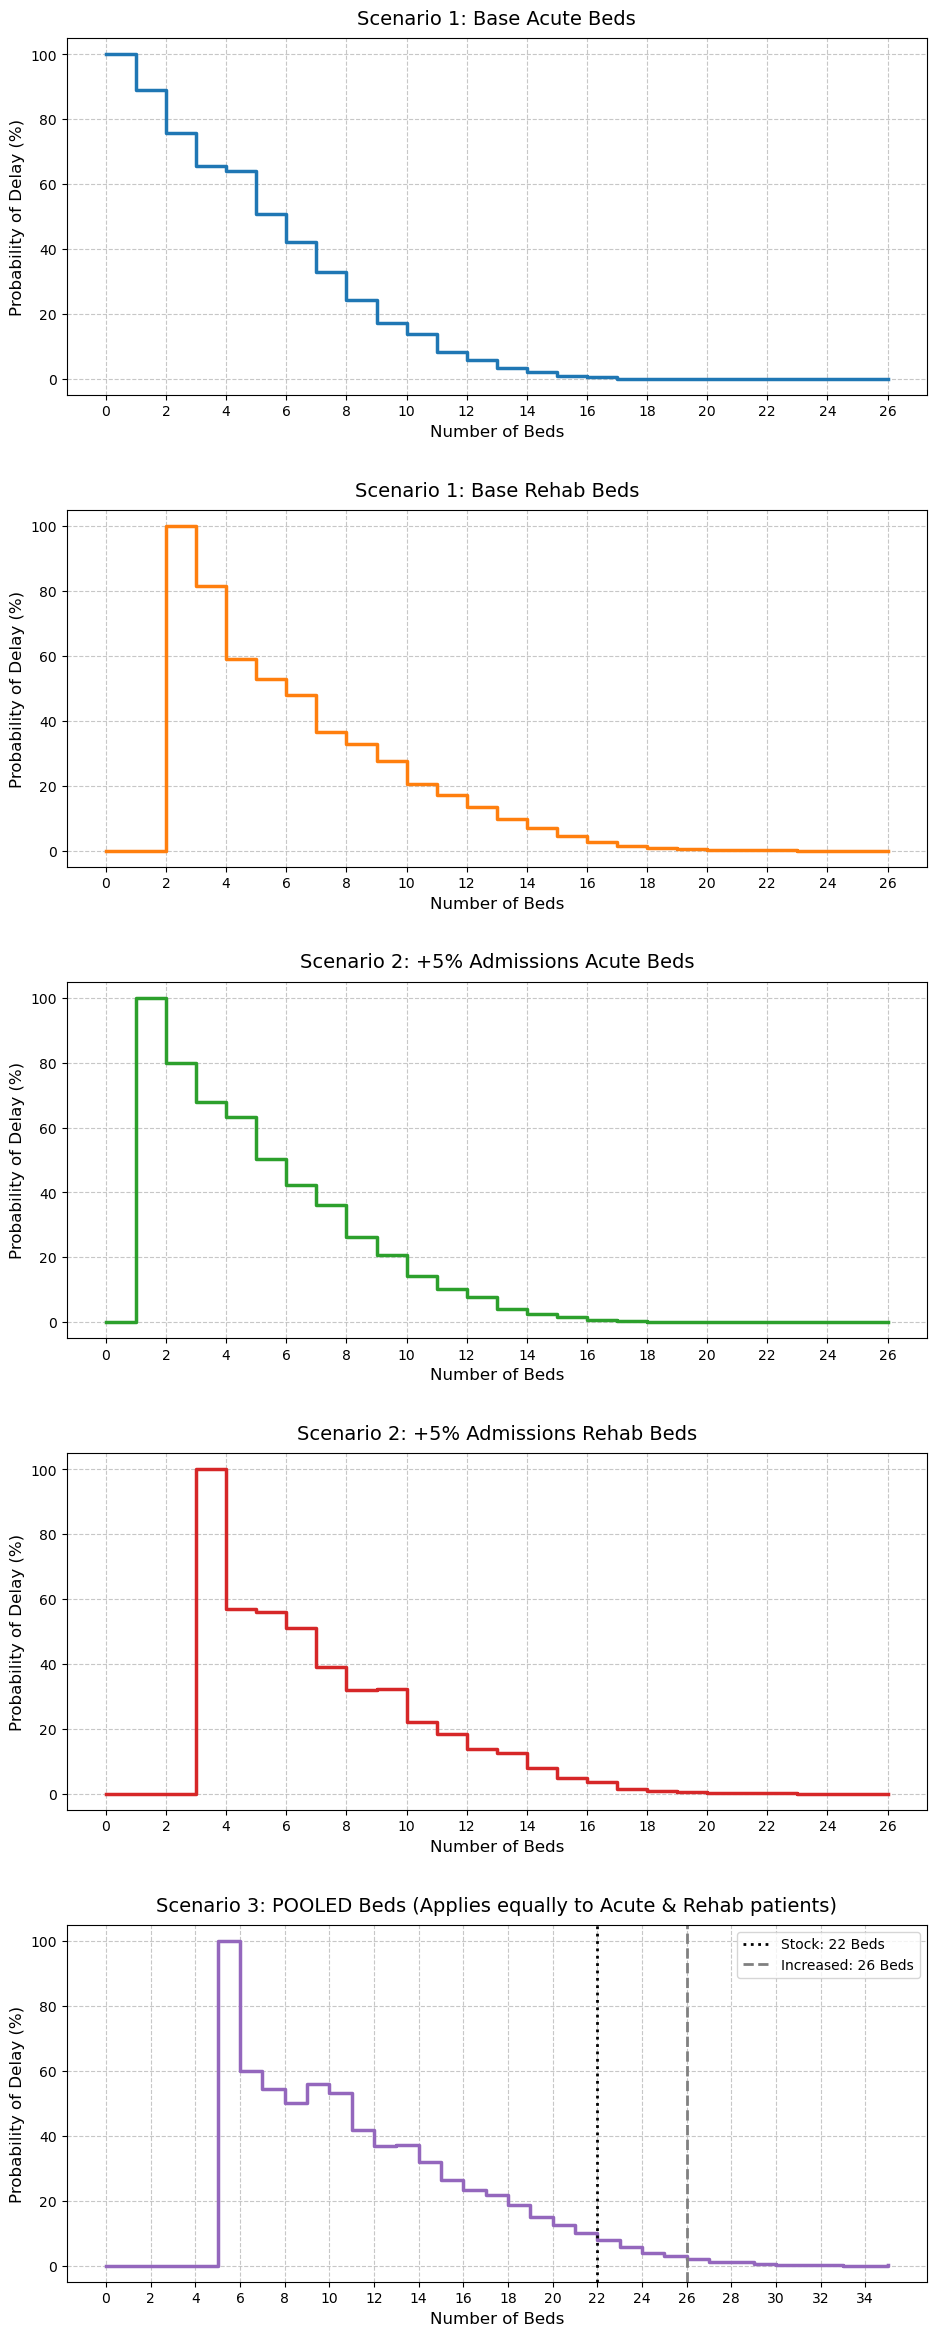

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Trace utility function as a debug print switch
# ---------------------------------------------------------
TRACE = False

def trace(msg):
    if TRACE:
        print(msg)

# ---------------------------------------------------------
# 1. Build and sample from distribution classes
# ---------------------------------------------------------
class ExponentialDistribution:
    def __init__(self, mean, random_seed=None):
        self.mean = mean
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.exponential(scale=self.mean)

class LognormalDistribution:
    def __init__(self, sample_mean, sample_stdev, random_seed=None):
        variance = sample_stdev ** 2
        self.mu = np.log((sample_mean ** 2) / np.sqrt(variance + sample_mean ** 2))
        self.sigma = np.sqrt(np.log(1 + (variance / sample_mean ** 2)))
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.lognormal(mean=self.mu, sigma=self.sigma)

# ---------------------------------------------------------
# 3. Create a parameter container class called Scenario
# ---------------------------------------------------------
class Scenario:
    def __init__(self, admissions_multiplier=1.0):
        self.random_seed = 42
        
        # Simulation Runtime Parameters
        self.warm_up_days = 3 * 365
        self.run_days = 10 * 365
        
        # Unconstrained capacities to measure offered load
        self.acute_beds_capacity = 9999 
        self.rehab_beds_capacity = 9999 
        
        # Evaluation ranges for Erlang formulas
        self.separate_eval_range = range(0, 27) # 0 to 26 for individual wards
        self.pooled_eval_range = range(0, 36)   # 0 to 35 for pooled to capture 22 & 26
        
        base_acute_iat = {
            'Acute stroke': 1.2, 'TIA': 9.3, 'Complex neurological': 3.6, 'Other': 3.2
        }
        self.acute_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_acute_iat.items()
        }
        
        base_rehab_iat = {
            'Acute stroke': 21.8, 'Complex neurological': 31.7, 'Other': 28.6
        }
        self.rehab_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_rehab_iat.items()
        }
        
        self.acute_destinations = ['Rehab', 'ESD', 'Other']
        self.acute_transfer_matrix = {
            'Acute stroke': [0.24, 0.13, 0.63], 'TIA': [0.01, 0.01, 0.98],
            'Complex neurological': [0.11, 0.05, 0.84], 'Other': [0.05, 0.10, 0.85]
        }
        
        self.rehab_destinations = ['ESD', 'Other']
        self.rehab_transfer_matrix = {
            'Acute stroke': [0.40, 0.60], 'TIA': [0.00, 1.00],
            'Complex neurological': [0.09, 0.91], 'Other': [0.13, 0.87] 
        }
        
        self.acute_los_params = {
            'Acute stroke': {'Rehab': (7.4, 8.6), 'ESD': (4.6, 4.8), 'Other': (7.4, 8.6)},
            'TIA': {dest: (1.8, 2.3) for dest in self.acute_destinations},
            'Complex neurological': {dest: (4.0, 5.0) for dest in self.acute_destinations},
            'Other': {dest: (3.8, 5.2) for dest in self.acute_destinations}
        }
        
        self.rehab_los_params = {
            'Acute stroke': {'ESD': (30.3, 23.1), 'Other': (28.4, 27.2)},
            'TIA': {dest: (18.7, 23.5) for dest in self.rehab_destinations},
            'Complex neurological': {dest: (27.6, 28.4) for dest in self.rehab_destinations},
            'Other': {dest: (16.1, 14.1) for dest in self.rehab_destinations}
        }

# ---------------------------------------------------------
# 4. Create a patient class called AcutePatient
# ---------------------------------------------------------
class AcutePatient:
    def __init__(self, p_id, p_type, arrival_time, source="Acute"):
        self.id = p_id
        self.type = p_type
        self.arrival_time = arrival_time
        self.source = source
        self.acute_destination = None
        self.rehab_destination = None

# ---------------------------------------------------------
# 5. Create a model class called StrokeUnit
# ---------------------------------------------------------
class StrokeUnit:
    def __init__(self, env, scenario):
        self.env = env
        self.scenario = scenario
        self.patient_counter = 0
        
        self.daily_acute_occupancy = []
        self.daily_rehab_occupancy = []
        self.daily_total_occupancy = [] # Added for the pooled scenario
        
        self.acute_beds = simpy.Resource(env, capacity=self.scenario.acute_beds_capacity)
        self.rehab_beds = simpy.Resource(env, capacity=self.scenario.rehab_beds_capacity)
        
        self.acute_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 100)
        self.rehab_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 200)
        
        self.acute_arrival_dists = {}
        self.rehab_arrival_dists = {}
        self.acute_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        self.rehab_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        
        dist_seed = self.scenario.random_seed + 1000
        
        for p_type, mean_iat in self.scenario.acute_inter_arrival_means.items():
            self.acute_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            for dest in self.scenario.acute_destinations:
                mean, stdev = self.scenario.acute_los_params[p_type][dest]
                self.acute_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1
                
        for p_type, mean_iat in self.scenario.rehab_inter_arrival_means.items():
            self.rehab_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            for dest in self.scenario.rehab_destinations:
                mean, stdev = self.scenario.rehab_los_params[p_type][dest]
                self.rehab_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1

    def daily_audit(self):
        yield self.env.timeout(self.scenario.warm_up_days)
        while True:
            # Audit separate and pooled occupancies
            acc = len(self.acute_beds.users)
            reh = len(self.rehab_beds.users)
            self.daily_acute_occupancy.append(acc)
            self.daily_rehab_occupancy.append(reh)
            self.daily_total_occupancy.append(acc + reh) # Pooled load
            yield self.env.timeout(1.0)

    def acute_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.acute_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Acute")
            self.env.process(self.acute_process(patient))

    def rehab_direct_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.rehab_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Direct Rehab")
            self.env.process(self.rehab_process(patient))

    def acute_process(self, patient):
        probs = self.scenario.acute_transfer_matrix[patient.type]
        patient.acute_destination = self.acute_routing_rng.choice(self.scenario.acute_destinations, p=probs)
        
        with self.acute_beds.request() as req:
            yield req
            los = self.acute_los_dists[patient.type][patient.acute_destination].sample()
            yield self.env.timeout(los)
            
            if patient.acute_destination == 'Rehab':
                self.env.process(self.rehab_process(patient))

    def rehab_process(self, patient):
        probs = self.scenario.rehab_transfer_matrix[patient.type]
        patient.rehab_destination = self.rehab_routing_rng.choice(self.scenario.rehab_destinations, p=probs)
        
        with self.rehab_beds.request() as req:
            yield req
            los = self.rehab_los_dists[patient.type][patient.rehab_destination].sample()
            yield self.env.timeout(los)

    def run_simulation(self):
        self.env.process(self.daily_audit())
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            self.env.process(self.acute_arrivals_generator(p_type))
        for p_type in self.scenario.rehab_inter_arrival_means.keys():
            self.env.process(self.rehab_direct_arrivals_generator(p_type))

# =========================================================
# Analysis & Plotting Functions
# =========================================================
def calculate_p_delay_curve(occupancy_data, capacity_range):
    if not occupancy_data:
        return {}
        
    max_eval_capacity = max(capacity_range)
    max_actual_occupancy = max(occupancy_data)
    array_size = max(max_eval_capacity, max_actual_occupancy) + 1
    
    counts = np.zeros(array_size)
    for occ in occupancy_data:
        counts[occ] += 1
        
    pdf = counts / len(occupancy_data)
    cdf = np.cumsum(pdf)
    
    results = {}
    for n in capacity_range:
        p_n = pdf[n]
        p_le_n = cdf[n]
        p_delay = p_n / p_le_n if p_le_n > 0 else 0.0
        results[n] = p_delay
        
    return results

def print_table(title, occupancy_data, results, highlight_beds=None):
    print(f"\n{title}")
    print(f"Mean Unconstrained Occupancy: {np.mean(occupancy_data):.2f} beds")
    print("Capacity | P(delay) | % Delayed")
    print("---------------------------------")
    for beds, p_delay in results.items():
        marker = " <---" if highlight_beds and beds in highlight_beds else ""
        # Only print a subset if the list is long, to save terminal space, but ensure highlights are shown
        if beds % 2 == 0 or marker: 
            print(f" {beds:6d}  |  {p_delay:.4f}  | {p_delay*100:7.2f}%{marker}")

def plot_five_tradeoff_curves(base_a, base_r, inc_a, inc_r, pooled):
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 24))
    
    datasets = [
        (base_a, 'Scenario 1: Base Acute Beds', '#1f77b4'),
        (base_r, 'Scenario 1: Base Rehab Beds', '#ff7f0e'),
        (inc_a, 'Scenario 2: +5% Admissions Acute Beds', '#2ca02c'),
        (inc_r, 'Scenario 2: +5% Admissions Rehab Beds', '#d62728'),
        (pooled, 'Scenario 3: POOLED Beds (Applies equally to Acute & Rehab patients)', '#9467bd')
    ]
    
    for ax, (data_dict, title, color) in zip(axes, datasets):
        beds = list(data_dict.keys())
        p_delay_pct = [val * 100 for val in data_dict.values()]
        ax.step(beds, p_delay_pct, where='post', color=color, linewidth=2.5)
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('Number of Beds', fontsize=12)
        ax.set_ylabel('Probability of Delay (%)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(beds[::2])
        ax.set_ylim(-5, 105)
        
        # Add special vertical lines for the pooled graph
        if 'POOLED' in title:
            ax.axvline(x=22, color='black', linestyle=':', linewidth=2, label='Stock: 22 Beds')
            ax.axvline(x=26, color='gray', linestyle='--', linewidth=2, label='Increased: 26 Beds')
            ax.legend()
        
    plt.tight_layout(pad=3.0)
    plt.show()

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    # 1. Run Base Scenario (Provides data for Scenario 1 & 3)
    print("--- Running BASE Scenario Simulation ---")
    base_scenario = Scenario(admissions_multiplier=1.0)
    env_base = simpy.Environment()
    model_base = StrokeUnit(env_base, base_scenario)
    model_base.run_simulation()
    env_base.run(until=base_scenario.warm_up_days + base_scenario.run_days)
    
    base_acute_results = calculate_p_delay_curve(model_base.daily_acute_occupancy, base_scenario.separate_eval_range)
    base_rehab_results = calculate_p_delay_curve(model_base.daily_rehab_occupancy, base_scenario.separate_eval_range)
    pooled_results = calculate_p_delay_curve(model_base.daily_total_occupancy, base_scenario.pooled_eval_range)

    # 2. Run +5% Scenario (Provides data for Scenario 2)
    print("\n--- Running +5% ADMISSIONS Scenario Simulation ---")
    inc_scenario = Scenario(admissions_multiplier=1.05)
    env_inc = simpy.Environment()
    model_inc = StrokeUnit(env_inc, inc_scenario)
    model_inc.run_simulation()
    env_inc.run(until=inc_scenario.warm_up_days + inc_scenario.run_days)
    
    inc_acute_results = calculate_p_delay_curve(model_inc.daily_acute_occupancy, inc_scenario.separate_eval_range)
    inc_rehab_results = calculate_p_delay_curve(model_inc.daily_rehab_occupancy, inc_scenario.separate_eval_range)

    # 3. Print Vertically Stacked Tables
    print_table("=== SCENARIO 1: BASE ACUTE BEDS ===", model_base.daily_acute_occupancy, base_acute_results)
    print_table("=== SCENARIO 1: BASE REHAB BEDS ===", model_base.daily_rehab_occupancy, base_rehab_results)
    
    print_table("=== SCENARIO 2: +5% ADMISSIONS ACUTE BEDS ===", model_inc.daily_acute_occupancy, inc_acute_results)
    print_table("=== SCENARIO 2: +5% ADMISSIONS REHAB BEDS ===", model_inc.daily_rehab_occupancy, inc_rehab_results)
    
    print("\nNote: In a pooled model, both acute and rehab patients queue for the exact same resource pool.")
    print("Therefore, the P(delay) is identical for both patient types.")
    print_table("=== SCENARIO 3: POOLED BEDS (Base Admissions) ===", model_base.daily_total_occupancy, pooled_results, highlight_beds=[22, 26])

    # 4. Generate the 5-Pane Plot
    print("\nGenerating Matplotlib visualization...")
    plot_five_tradeoff_curves(base_acute_results, base_rehab_results, inc_acute_results, inc_rehab_results, pooled_results)